## XGBoost + Incremental Retraining

In [43]:
import os
import pandas as pd
import numpy as np
from datetime import date
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir('/Users/anasantana/Desktop/copa')

# ── Data cleaning ─────────────────────────────────────────────────────────────
results   = pd.read_csv('results.csv',      parse_dates=['date'])
shootouts = pd.read_csv('shootouts.csv',    parse_dates=['date'])
fnames    = pd.read_csv('former_names.csv', parse_dates=['start_date','end_date'])

name_map = dict(zip(fnames['former'], fnames['current']))
def normalize_team(name): return name_map.get(name, name)
for col in ['home_team','away_team']:
    results[col]   = results[col].map(normalize_team)
    shootouts[col] = shootouts[col].map(normalize_team)
shootouts['winner'] = shootouts['winner'].map(normalize_team)

shootouts_slim = shootouts[['date','home_team','away_team','winner']].rename(columns={'winner':'shootout_winner'})
df = results.merge(shootouts_slim, on=['date','home_team','away_team'], how='left')

def true_winner(row):
    if pd.notna(row['shootout_winner']): return row['shootout_winner']
    elif row['home_score'] > row['away_score']: return row['home_team']
    elif row['away_score'] > row['home_score']: return row['away_team']
    else: return 'Draw'
df['winner'] = df.apply(true_winner, axis=1)

wc2026_matches = df[(df['tournament']=='FIFA World Cup') & (df['date'].dt.year==2026)]
WC2026_TEAMS   = set(wc2026_matches['home_team'].tolist() + wc2026_matches['away_team'].tolist())
both_wc   = df['home_team'].isin(WC2026_TEAMS) & df['away_team'].isin(WC2026_TEAMS)
is_wc2026 = (df['tournament']=='FIFA World Cup') & (df['date'].dt.year==2026)

train           = df[both_wc & (df['date'] < '2023-01-01') & ~is_wc2026].copy().sort_values('date').reset_index(drop=True)
historical_test = df[both_wc & (df['date'] >= '2023-01-01') & ~is_wc2026].copy().sort_values('date').reset_index(drop=True)
wc_test         = df[is_wc2026].copy().sort_values('date').reset_index(drop=True)

TODAY = pd.Timestamp(date.today())
def recency_weight(d):
    days = (TODAY - d).days
    if days <= 365*3: return 3.0
    elif days <= 365*8: return 2.0
    else: return 1.0
MAJOR = {'FIFA World Cup','Copa América','UEFA Euro','Africa Cup of Nations','AFC Asian Cup','CONCACAF Gold Cup'}
def t_weight(t):
    if t in MAJOR: return 2.0
    elif 'qualifier' in t.lower() or 'qualification' in t.lower(): return 1.5
    else: return 1.0
train['recency_weight']    = train['date'].apply(recency_weight)
train['tournament_weight'] = train['tournament'].apply(t_weight)
train['weight']            = train['recency_weight'] * train['tournament_weight']

# ── Feature engineering ────────────────────────────────────────────────────────
def compute_team_stats(train_df):
    home = train_df[['home_team','home_score','away_score','winner','weight']].copy()
    home.columns = ['team','scored','conceded','winner','weight']
    home['won'] = (home['winner']==home['team']).astype(float)
    home['drew'] = (home['winner']=='Draw').astype(float)
    home['goal_diff'] = home['scored'] - home['conceded']
    away = train_df[['away_team','away_score','home_score','winner','weight']].copy()
    away.columns = ['team','scored','conceded','winner','weight']
    away['won'] = (away['winner']==away['team']).astype(float)
    away['drew'] = (away['winner']=='Draw').astype(float)
    away['goal_diff'] = away['scored'] - away['conceded']
    all_games = pd.concat([home, away], ignore_index=True)
    def wavg(g, col): return np.average(g[col], weights=g['weight'])
    return all_games.groupby('team').apply(
        lambda g: pd.Series({'attack': wavg(g,'scored'), 'defense': wavg(g,'conceded'),
                             'win_rate': wavg(g,'won'), 'draw_rate': wavg(g,'drew'),
                             'goal_diff': wavg(g,'goal_diff'), 'games': len(g)})
    ).reset_index()

def compute_recent_form(train_df, n=5):
    home = train_df[['date','home_team','winner']].rename(columns={'home_team':'team'})
    away = train_df[['date','away_team','winner']].rename(columns={'away_team':'team'})
    all_games = pd.concat([home, away]).sort_values('date')
    def pts(row):
        if row['winner']==row['team']: return 3
        elif row['winner']=='Draw': return 1
        else: return 0
    all_games['points'] = all_games.apply(pts, axis=1)
    return (all_games.groupby('team').tail(n)
            .groupby('team')['points'].sum().reset_index().rename(columns={'points':'form'}))

def h2h_win_rate(team_a, team_b, train_df):
    mask = (((train_df['home_team']==team_a)&(train_df['away_team']==team_b))|
            ((train_df['home_team']==team_b)&(train_df['away_team']==team_a)))
    h2h = train_df[mask].copy()
    if len(h2h)==0: return 0.5
    h2h['a_won'] = (h2h['winner']==team_a).astype(float)
    return np.average(h2h['a_won'], weights=h2h['weight'])

def h2h_draw_rate(team_a, team_b, train_df):
    mask = (((train_df['home_team']==team_a)&(train_df['away_team']==team_b))|
            ((train_df['home_team']==team_b)&(train_df['away_team']==team_a)))
    h2h = train_df[mask].copy()
    if len(h2h)==0: return 0.25
    h2h['drew'] = (h2h['winner']=='Draw').astype(float)
    return np.average(h2h['drew'], weights=h2h['weight'])

def build_stats_lookup(train_df):
    ts = compute_team_stats(train_df)
    rf = compute_recent_form(train_df)
    return ts.merge(rf, on='team', how='left').set_index('team').to_dict('index')

FEATURE_COLS = [
    'a_attack','b_attack','a_defense','b_defense',
    'a_win_rate','b_win_rate','a_draw_rate','b_draw_rate',
    'a_goal_diff','b_goal_diff','a_form','b_form',
    'attack_diff','defense_diff','win_rate_diff','goal_diff_diff','form_diff',
    'h2h_a_win_rate','h2h_draw_rate','is_neutral'
]

def build_features(match_df, train_df, label=True):
    lookup = build_stats_lookup(train_df)
    def gs(team, stat): return lookup.get(team, {}).get(stat, 0)
    rows = []
    for _, row in match_df.iterrows():
        a, b = row['home_team'], row['away_team']
        neutral = 1 if str(row.get('neutral', False)).upper() == 'TRUE' else 0
        feat = {
            'team_a': a, 'team_b': b, 'date': row['date'],
            'a_attack': gs(a,'attack'),       'b_attack': gs(b,'attack'),
            'a_defense': gs(a,'defense'),     'b_defense': gs(b,'defense'),
            'a_win_rate': gs(a,'win_rate'),   'b_win_rate': gs(b,'win_rate'),
            'a_draw_rate': gs(a,'draw_rate'), 'b_draw_rate': gs(b,'draw_rate'),
            'a_goal_diff': gs(a,'goal_diff'), 'b_goal_diff': gs(b,'goal_diff'),
            'a_form': gs(a,'form'),           'b_form': gs(b,'form'),
            'attack_diff':    gs(a,'attack')    - gs(b,'attack'),
            'defense_diff':   gs(a,'defense')   - gs(b,'defense'),
            'win_rate_diff':  gs(a,'win_rate')  - gs(b,'win_rate'),
            'goal_diff_diff': gs(a,'goal_diff') - gs(b,'goal_diff'),
            'form_diff':      gs(a,'form')      - gs(b,'form'),
            'h2h_a_win_rate': h2h_win_rate(a, b, train_df),
            'h2h_draw_rate':  h2h_draw_rate(a, b, train_df),
            'is_neutral': neutral,
        }
        if label:
            if row['winner']==a:        feat['outcome'] = 1
            elif row['winner']=='Draw': feat['outcome'] = 0
            else:                       feat['outcome'] = -1
        rows.append(feat)
    return pd.DataFrame(rows)

train_features     = build_features(train,           train)
hist_test_features = build_features(historical_test, train)
wc_test_features   = build_features(wc_test,         train)
print('Setup complete.')

/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(
/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(


Setup complete.


/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(


## 1. Two-Stage XGBoost

Instead of predicting 3 classes at once (win/draw/loss), I split into two simpler problems:

**Stage 1** — Is this match going to be a draw?
- Binary: draw (1) vs decisive result (0)
- Uses draw_rate features and h2h_draw_rate to spot draw-prone matchups

**Stage 2** — If it's decisive, who wins?
- Binary: team_a wins (1) vs team_b wins (0)
- Trained only on non-draw matches — no noise from draws

**Final prediction** — if Stage 1 says draw probability > threshold → predict draw, else use Stage 2.

In [44]:
def train_two_stage(train_feat_df, draw_threshold=0.35):
    X = train_feat_df[FEATURE_COLS]
    y = train_feat_df['outcome']
    w = train_feat_df['date'].apply(recency_weight)

    # Stage 1: draw vs decisive
    y_draw = (y == 0).astype(int)
    stage1 = xgb.XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    )
    stage1.fit(X, y_draw, sample_weight=w)

    # Stage 2: who wins (decisive matches only)
    decisive_mask = y != 0
    X_dec = X[decisive_mask]
    y_dec = (y[decisive_mask] == 1).astype(int)  # 1 = team_a wins, 0 = team_b wins
    w_dec = w[decisive_mask]
    stage2 = xgb.XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    )
    stage2.fit(X_dec, y_dec, sample_weight=w_dec)

    return stage1, stage2

def two_stage_predict(X, stage1, stage2, draw_threshold=0.35):
    p_draw   = stage1.predict_proba(X)[:, 1]
    p_a_wins = stage2.predict_proba(X)[:, 1]
    preds = []
    for i in range(len(X)):
        if p_draw[i] >= draw_threshold:
            preds.append(0)   # Draw
        else:
            preds.append(1 if p_a_wins[i] >= 0.5 else -1)
    return np.array(preds)

def two_stage_proba(X, stage1, stage2):
    """Return (p_a_wins, p_draw, p_b_wins) for each match."""
    p_draw_raw = stage1.predict_proba(X)[:, 1]
    p_a_wins   = stage2.predict_proba(X)[:, 1]
    p_b_wins   = 1 - p_a_wins
    # Scale decisive probs by (1 - p_draw)
    p_a = p_a_wins * (1 - p_draw_raw)
    p_b = p_b_wins * (1 - p_draw_raw)
    return p_a, p_draw_raw, p_b

stage1, stage2 = train_two_stage(train_features)
print('Two-stage model trained.')

Two-stage model trained.


## 2. Tune draw threshold on historical test set

The draw threshold controls how confidently Stage 1 needs to say 'draw' before we predict one.
We tune it on 2023-2025 data so it's optimized before touching the WC.

In [45]:
X_hist = hist_test_features[FEATURE_COLS]
y_hist = hist_test_features['outcome'].values

best_threshold, best_acc = 0.35, 0
for threshold in np.arange(0.20, 0.75, 0.05):
    preds = two_stage_predict(X_hist, stage1, stage2, threshold)
    acc   = accuracy_score(y_hist, preds)
    print(f'  threshold={threshold:.2f}  →  accuracy={acc:.1%}')
    if acc > best_acc:
        best_acc, best_threshold = acc, threshold

print(f'\nBest threshold: {best_threshold:.2f}  (accuracy: {best_acc:.1%} on historical test)')

  threshold=0.20  →  accuracy=36.2%
  threshold=0.25  →  accuracy=38.7%
  threshold=0.30  →  accuracy=41.2%
  threshold=0.35  →  accuracy=42.2%
  threshold=0.40  →  accuracy=41.9%
  threshold=0.45  →  accuracy=42.4%
  threshold=0.50  →  accuracy=43.4%
  threshold=0.55  →  accuracy=42.9%
  threshold=0.60  →  accuracy=44.2%
  threshold=0.65  →  accuracy=44.4%
  threshold=0.70  →  accuracy=44.9%

Best threshold: 0.70  (accuracy: 44.9% on historical test)


# 3. Evaluate on WC 2026 games

So how well does the model predict the actual WC 2026
results it has never seen? ***before incremental retraining

In [46]:
X_wc = wc_test_features[FEATURE_COLS]
y_wc = wc_test_features['outcome'].values

wc_preds = two_stage_predict(X_wc, stage1, stage2, best_threshold)
wc_acc   = accuracy_score(y_wc, wc_preds)
print(f'WC 2026 accuracy (baseline, no incremental retraining): {wc_acc:.1%}')
print(classification_report(y_wc, wc_preds, target_names=['B wins','Draw','A wins']))

WC 2026 accuracy (baseline, no incremental retraining): 38.9%
              precision    recall  f1-score   support

      B wins       0.19      0.44      0.27         9
        Draw       0.67      0.11      0.18        38
      A wins       0.44      0.80      0.57        25

    accuracy                           0.39        72
   macro avg       0.43      0.45      0.34        72
weighted avg       0.53      0.39      0.33        72



## 4. Incremental retraining by WC round

After each round I add those results to training and retrain both stages.
This is where the model truly adapts to the world cup 2026.

In [47]:
ROUND_CUTOFFS = [
    ('Round 1', '2026-06-11', '2026-06-17'),
    ('Round 2', '2026-06-18', '2026-06-22'),
    ('Round 3', '2026-06-23', '2026-06-27'),
]

all_predictions = []
current_train   = train.copy()
current_stage1, current_stage2 = stage1, stage2

for round_name, round_start, round_end in ROUND_CUTOFFS:
    round_mask    = (wc_test['date'] >= round_start) & (wc_test['date'] <= round_end)
    round_matches = wc_test[round_mask].copy()
    if len(round_matches) == 0: continue

    round_features = build_features(round_matches, current_train)
    X_round = round_features[FEATURE_COLS]
    y_round = round_features['outcome'].values

    round_preds = two_stage_predict(X_round, current_stage1, current_stage2, best_threshold)
    round_acc   = accuracy_score(y_round, round_preds)

    round_features['predicted'] = round_preds
    round_features['actual']    = y_round
    round_features['correct']   = round_features['predicted'] == round_features['actual']
    round_features['round']     = round_name
    all_predictions.append(round_features)

    print(f'{round_name}: {round_acc:.1%} accuracy ({round_features["correct"].sum()}/{len(round_features)} correct)')

    # Add round results to training and retrain
    round_matches['recency_weight']    = round_matches['date'].apply(recency_weight)
    round_matches['tournament_weight'] = round_matches['tournament'].apply(t_weight)
    round_matches['weight']            = round_matches['recency_weight'] * round_matches['tournament_weight']
    current_train = pd.concat([current_train, round_matches], ignore_index=True)

    new_features = build_features(current_train, current_train)
    current_stage1, current_stage2 = train_two_stage(new_features, best_threshold)

print('\nIncremental retraining complete.')

Round 1: 41.7% accuracy (10/24 correct)


/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(
/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(
/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715

Round 2: 65.0% accuracy (13/20 correct)


/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(
/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(


Round 3: 25.0% accuracy (7/28 correct)

Incremental retraining complete.


In [48]:
#full results table

label_map = {1: 'A wins', 0: 'Draw', -1: 'B wins'}
all_preds_df = pd.concat(all_predictions, ignore_index=True)
all_preds_df['predicted_label'] = all_preds_df['predicted'].map(label_map)
all_preds_df['actual_label']    = all_preds_df['actual'].map(label_map)

print(f'Overall WC 2026 accuracy: {all_preds_df["correct"].mean():.1%}')
all_preds_df[['round','date','team_a','team_b','predicted_label','actual_label','correct']]

Overall WC 2026 accuracy: 41.7%


,round,date,team_a,team_b,predicted_label,actual_label,correct
0,Round 1,2026-06-11,Mexico,South Africa,A wins,A wins,True
1,Round 1,2026-06-11,South Korea,Czech Republic,A wins,A wins,True
2,Round 1,2026-06-12,Canada,Bosnia and Herzegovina,A wins,Draw,False
3,Round 1,2026-06-12,United States,Paraguay,A wins,A wins,True
4,Round 1,2026-06-13,Qatar,Switzerland,A wins,Draw,False
...,...,...,...,...,...,...,...
67,Round 3,2026-06-27,Algeria,Austria,B wins,Draw,False
68,Round 3,2026-06-27,Jordan,Argentina,B wins,Draw,False
69,Round 3,2026-06-27,Colombia,Portugal,A wins,Draw,False
70,Round 3,2026-06-27,DR Congo,Uzbekistan,A wins,Draw,False


## 6. Feature importances — Stage 1 (draw detection) and Stage 2 (winner)

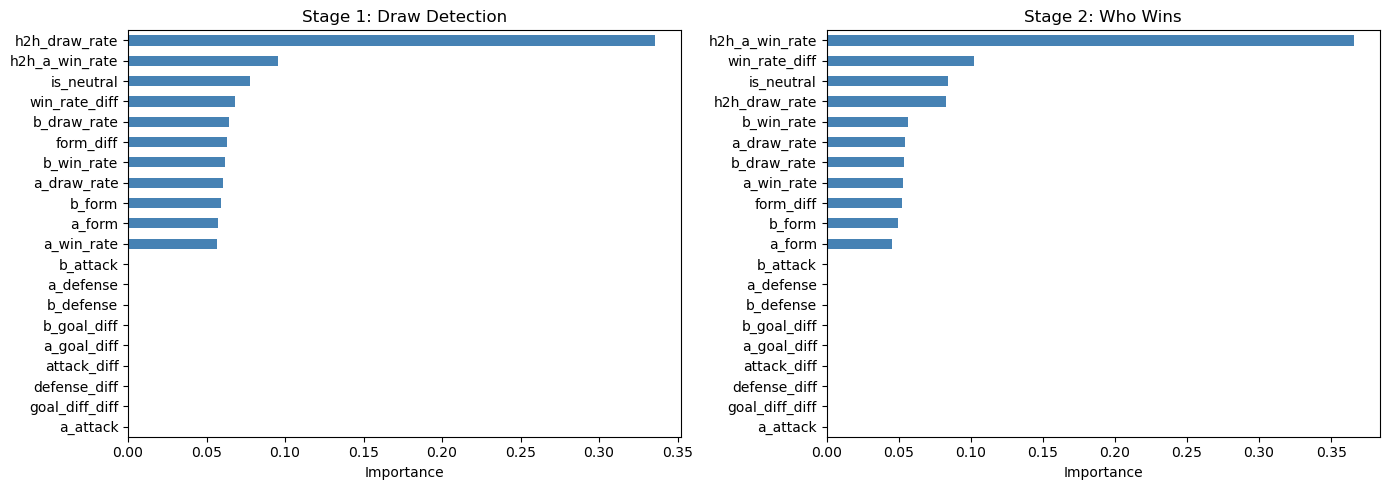

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in [
    (axes[0], current_stage1, 'Stage 1: Draw Detection'),
    (axes[1], current_stage2, 'Stage 2: Who Wins'),
]:
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [51]:
def predict_match(team_a, team_b):
    lookup = build_stats_lookup(current_train)
    def gs(team, stat): return lookup.get(team, {}).get(stat, 0)
    feat = {
        'a_attack': gs(team_a,'attack'),       'b_attack': gs(team_b,'attack'),
        'a_defense': gs(team_a,'defense'),     'b_defense': gs(team_b,'defense'),
        'a_win_rate': gs(team_a,'win_rate'),   'b_win_rate': gs(team_b,'win_rate'),
        'a_draw_rate': gs(team_a,'draw_rate'), 'b_draw_rate': gs(team_b,'draw_rate'),
        'a_goal_diff': gs(team_a,'goal_diff'), 'b_goal_diff': gs(team_b,'goal_diff'),
        'a_form': gs(team_a,'form'),           'b_form': gs(team_b,'form'),
        'attack_diff':    gs(team_a,'attack')    - gs(team_b,'attack'),
        'defense_diff':   gs(team_a,'defense')   - gs(team_b,'defense'),
        'win_rate_diff':  gs(team_a,'win_rate')  - gs(team_b,'win_rate'),
        'goal_diff_diff': gs(team_a,'goal_diff') - gs(team_b,'goal_diff'),
        'form_diff':      gs(team_a,'form')      - gs(team_b,'form'),
        'h2h_a_win_rate': h2h_win_rate(team_a, team_b, current_train),
        'h2h_draw_rate':  h2h_draw_rate(team_a, team_b, current_train),
        'is_neutral': 1,  # WC games are always neutral
    }
    X = pd.DataFrame([feat])[FEATURE_COLS]
    p_a, p_draw, p_b = two_stage_proba(X, current_stage1, current_stage2)
    p_a, p_draw, p_b = p_a[0], p_draw[0], p_b[0]

    if p_draw >= best_threshold:
        prediction = 'Draw'
    else:
        prediction = team_a if p_a >= p_b else team_b

    print(f'\n{team_a} vs {team_b}')
    print(f'  {team_a} wins: {p_a:.1%}')
    print(f'  Draw:          {p_draw:.1%}')
    print(f'  {team_b} wins: {p_b:.1%}')
    print(f'  → Prediction: {prediction}')

#examples
predict_match('Brazil', 'Scotland')
predict_match('Australia', 'Paraguay')
predict_match('Japan', 'Sweden')

/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(



Brazil vs Scotland
  Brazil wins: 88.1%
  Draw:          10.2%
  Scotland wins: 1.7%
  → Prediction: Brazil

Australia vs Paraguay
  Australia wins: 29.0%
  Draw:          68.5%
  Paraguay wins: 2.5%
  → Prediction: Australia

Japan vs Sweden
  Japan wins: 0.1%
  Draw:          75.0%
  Sweden wins: 24.9%
  → Prediction: Draw


/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(
/var/folders/gt/srhy4gnd3js3k460dfgpn0q40000gn/T/ipykernel_25382/3635715793.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return all_games.groupby('team').apply(
